# Figure 5 supplement panel F

In [1]:
import os

import pandas as pd
import numpy as np
from lifelines import AalenJohansenFitter
from lifelines.statistics import multivariate_logrank_test

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, PercentFormatter
import seaborn as sns

In [2]:
sns.set(style='white')

# --- Manuscript plotting style ---
axis_label_font_size = 7
tick_label_font_size = 6
plt.rcParams.update({
    'font.size': axis_label_font_size,
    'axes.titlesize': axis_label_font_size,
    'axes.labelsize': axis_label_font_size,
    'xtick.labelsize': tick_label_font_size,
    'ytick.labelsize': tick_label_font_size,
    'legend.fontsize': tick_label_font_size,
    'legend.title_fontsize': axis_label_font_size,
})
font_size = tick_label_font_size  # used by the at-risk table

# --- Input path ---
INTERMEDIATE_DIR = 'intermediate_data/'

# --- Output path ---
FIGURE_DIR = 'figures/'
os.makedirs(FIGURE_DIR, exist_ok=True)

# --- Analysis configuration ---
EXP_NAME = 'first_pd1_lot_no_bmi'
EXP_NAME_TITLE = '1st LoTs containing PD1/PDL1 inhibitors'
LOCUS_OF_INTEREST = 'DRB1'
SEROTYPE_OF_INTEREST = 'DRB1*15'
ALLELES_OF_INTEREST = ['DRB1*15:01', 'DRB1*15:02', 'DRB1*15:03']
TOX_TYPE = 'adrenal_insufficiency'
AE_GRADE = 0  # 0 = Grade 1+


In [3]:
def get_cif_at_timepoints(ajf_fits, timepoints=[12, 15]):
    """Print CIF estimates and 95% CI at specific timepoints for each
    dosage group. ajf_fits: dict of {dosage_group: (ajf_fitter, sub_df)}
    from plot_cif_by_allele_dosage."""
    label_map = {
        0: 'Homozygous non-carrier',
        1: 'Heterozygous DRB1*15 carrier',
        2: 'Homozygous DRB1*15 carrier',
    }

    for g, (ajf, sub) in sorted(ajf_fits.items()):
        group_label = label_map.get(g, f'Dosage {g}')

        cif = ajf.cumulative_density_
        ci_lower = ajf.confidence_interval_cumulative_density_.filter(like='lower')
        ci_upper = ajf.confidence_interval_cumulative_density_.filter(like='upper')

        for t in timepoints:
            idx = cif.index[cif.index <= t]
            if len(idx) == 0:
                continue
            t_actual = idx[-1]
            est = cif.loc[t_actual].values[0]
            lo = ci_lower.loc[t_actual].values[0]
            hi = ci_upper.loc[t_actual].values[0]


def plot_cif_by_allele_dosage(
    df, exp_name, allele, locus, plot_out_dir_pos, tox_type, ae_grade, serotype_of_interest,
    time_col='t_event', event_col='ae_event', event_of_interest=1,
    min_n=1, min_events=1, title=None,
    colors={0: '#c6dbef', 1: '#6baed6', 2: '#08519c'},
):
    """Cumulative-incidence-function plot of `tox_type` by dosage (0/1/2
    copies) of `allele` (one or more IMGT allele names, e.g. the 3 DRB1*15
    subtypes), with an at-risk table. `df` is the cohort table written by
    this panel's data-generation notebook (`build_cif_cohort`). Identical
    to Figure 5 main panel G's `plot_cif_by_allele_dosage`, except that it
    never calls the ancestry-composition companion plot (not part of this
    panel)."""
    LW = 0.5

    if isinstance(allele, str):
        allele_set = {allele.strip().upper()}
    else:
        allele_set = {a.strip().upper() for a in allele}

    a1 = f'{locus}_1'
    a2 = f'{locus}_2'

    cols = [time_col, event_col, a1, a2]
    dd = df[cols].dropna().copy()

    if dd[event_col].dtype == bool:
        dd[event_col] = dd[event_col].astype(int)
    dd['time_months'] = dd[time_col] / 30.44

    dd['allele_dosage'] = (
        dd[a1].astype(str).str.strip().str.upper().isin(allele_set).astype(int) +
        dd[a2].astype(str).str.strip().str.upper().isin(allele_set).astype(int)
    )


    grp_summary = (
        dd.groupby('allele_dosage')
          .agg(n=('time_months', 'size'), n_event=(event_col, lambda x: (x == event_of_interest).sum()))
          .reset_index().sort_values('allele_dosage')
    )
    valid_groups = grp_summary[(grp_summary['n'] >= min_n) & (grp_summary['n_event'] >= min_events)]['allele_dosage'].tolist()
    if len(valid_groups) < 2:
        return grp_summary, np.nan
    dd = dd[dd['allele_dosage'].isin(valid_groups)].copy()

    dd['event_interest_only'] = (dd[event_col] == event_of_interest).astype(int)
    ref_group = sorted(valid_groups)[0]
    pval_per_group = {}
    for g in sorted(valid_groups):
        if g == ref_group:
            pval_per_group[g] = np.nan
        else:
            dd_pair = dd[dd['allele_dosage'].isin([ref_group, g])].copy()
            lr_pair = multivariate_logrank_test(
                event_durations=dd_pair[time_col], groups=dd_pair['allele_dosage'],
                event_observed=dd_pair['event_interest_only'],
            )
            pval_per_group[g] = lr_pair.p_value

    lr = multivariate_logrank_test(
        event_durations=dd[time_col], groups=dd['allele_dosage'], event_observed=dd['event_interest_only'],
    )
    p_lr = lr.p_value
    allele_label = '/'.join(sorted(allele_set))

    n_groups = len(sorted(valid_groups))
    if isinstance(colors, dict):
        color_map = colors
    elif isinstance(colors, (list, tuple)):
        color_map = {g: c for g, c in zip(sorted(valid_groups), colors)}
    else:
        color_map = {}

    fig = plt.figure(figsize=(2.5, 2.5 + n_groups * 0.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[5, n_groups * 0.4], hspace=0.5)
    ax = fig.add_subplot(gs[0])
    risk_ax = fig.add_subplot(gs[1], sharex=ax)
    plt.setp(ax.get_xticklabels(), visible=True)

    for spine in ax.spines.values():
        spine.set_linewidth(LW)
    ax.tick_params(width=LW)

    ajf_fits = {}
    for g in sorted(valid_groups):
        sub = dd[dd['allele_dosage'] == g].copy()
        label = 'dosage {}'.format(g)
        ajf = AalenJohansenFitter()
        ajf.fit(durations=sub['time_months'], event_observed=sub[event_col],
                event_of_interest=event_of_interest, label=label)
        plot_kw = dict(ax=ax, ci_show=False, lw=LW)
        if g in color_map:
            plot_kw['c'] = color_map[g]
        ajf.plot(**plot_kw)
        ajf_fits[g] = (ajf, sub)

    ax.set_xlabel('Months since LoT start')
    ax.set_ylabel('Cumulative incidence of \n{}'.format(tox_type.replace('_', ' ').title()))
    sns.despine(ax=ax)
    leg = ax.legend(loc='upper left', fontsize=tick_label_font_size, bbox_to_anchor=(1.05, 1), frameon=False)
    leg.set_title(serotype_of_interest, prop={'size': axis_label_font_size})
    ax.set_title((title or allele_label) + '\nLog-rank p={:.2e}'.format(p_lr))

    ax.set_xlim(left=0, right=18)
    xmax = ax.get_xlim()[1]
    max_cif = max(
        ajf.cumulative_density_.loc[ajf.cumulative_density_.index <= xmax].to_numpy().max()
        for ajf, _ in ajf_fits.values()
    )
    y_upper = min(1.0, max_cif * 1.25) if max_cif > 0 else 0.01
    ax.set_ylim(0, y_upper)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))

    x_ticks = np.array([0, 3, 6, 9, 12, 15, 18])
    risk_fontsize = font_size

    risk_ax.set_ylim(0, n_groups)
    risk_ax.axis('off')

    for row_idx, g in enumerate(sorted(valid_groups)):
        ajf, sub = ajf_fits[g]
        at_risk = [int((sub['time_months'] >= t).sum()) for t in x_ticks]
        y_pos = n_groups - row_idx - 0.5
        risk_ax.annotate(
            f'dosage {g}:', xy=(ax.get_xlim()[0], y_pos), xytext=(-6, 0), textcoords='offset points',
            ha='right', va='center', fontsize=risk_fontsize, annotation_clip=False,
        )
        for t, n_risk in zip(x_ticks, at_risk):
            risk_ax.text(t, y_pos, str(n_risk), ha='center', va='center', fontsize=risk_fontsize)

    ax.xaxis.set_tick_params(which='both', labelbottom=True)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(int(t)) for t in x_ticks])
    ax.set_xlabel('Months since LoT start')
    risk_ax.text(0.5, 0.0, 'Patients at risk', transform=risk_ax.transAxes, ha='center', va='top', fontsize=axis_label_font_size)
    ax.xaxis.label.set_visible(True)

    plt.tight_layout()

    plt.savefig(os.path.join(plot_out_dir_pos, f'fig5s_panel_f_{locus}_{exp_name}_{serotype_of_interest}_{tox_type}_grade{ae_grade}_cif.pdf'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(plot_out_dir_pos, f'fig5s_panel_f_{locus}_{exp_name}_{serotype_of_interest}_{tox_type}_grade{ae_grade}_cif.png'), dpi=300, bbox_inches='tight')

    get_cif_at_timepoints(ajf_fits, timepoints=[12, 15, 18])

    return grp_summary, p_lr


/var/folders/lm/b7fcsstn40g11jvck0m209_8fjcxsl/T/ipykernel_25836/3542981505.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


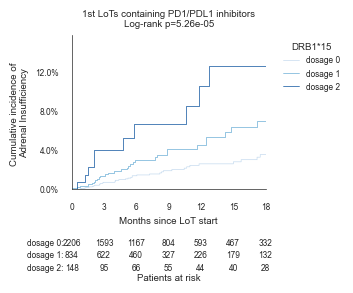

In [4]:
cohort_path = os.path.join(INTERMEDIATE_DIR, f'fig5s_panel_f_cohort_{TOX_TYPE}_grade{AE_GRADE}.csv')
df_plot = pd.read_csv(cohort_path)

plot_out_dir_pos = os.path.join(FIGURE_DIR, EXP_NAME, 'cif_by_hla_dosage', f'{TOX_TYPE}_grade{AE_GRADE}')
os.makedirs(plot_out_dir_pos, exist_ok=True)

grp_summary, p_lr = plot_cif_by_allele_dosage(
    df=df_plot,
    exp_name=EXP_NAME,
    allele=ALLELES_OF_INTEREST,
    locus=LOCUS_OF_INTEREST,
    plot_out_dir_pos=plot_out_dir_pos,
    tox_type=TOX_TYPE,
    ae_grade=AE_GRADE,
    serotype_of_interest=SEROTYPE_OF_INTEREST,
    time_col='t_event',
    event_col='ae_event',
    event_of_interest=1,
    min_n=0,
    min_events=0,
    title=EXP_NAME_TITLE,
)
